# Model comparison - ANN vs RNN vs LSTM
### Anaerobic Digestion of Olive Mill Waste - Crete Case Study

---

## Complete results from all 3 models

this notebook makes the final comparison across all 3 nn
architectures tested. all results come from the testing notebooks
where the models were evaluated on four held-out simulation runs covering different
corners of the operating space

**training metrics summary:**

| model | architecture | parameters | final Loss | dS R2 | dM R2 | dpH R2 |
|-------|-------------|------------|-----------|-------|-------|--------|
| ANN | Net(5,20,15,3) | 483 | 0.001549 | 0.9982 | 0.9984 | 0.9989 |
| RNN | RNNModel(5,20,1,3) | 603 | 0.000138 | 0.9993 | 0.9993 | 0.9977 |
| LSTM | LSTMModel(5,30,2,3) | 7,083 | 0.000114 | 0.9995 | 0.9995 | 0.9980 |

**online framework MAPE (actual state provided at each timestep):**

| Model | Mean S | Mean M | Mean pH |
|-------|--------|--------|---------|
| ANN | 0.07% | 0.06% | 0.00% |
| RNN | 0.56% | 2.76% | 0.06% |
| LSTM | 1.06% | 4.89% | 0.08% |

**offline framework MAPE (day 0 only, autonomous simulation):**

| Model | Mean S | Mean M | Mean pH | Verdict |
|-------|--------|--------|---------|---------|
| ANN | 0.45% | 0.29% | 0.02% | EXCELLENT |
| RNN | 24.02% | 17.19% | 1.02% | POOR |
| LSTM | 76.09% | 41.12% | 1.80% | UNACCEPTABLE |

**the biggest finding so far:**

training loss is not a reliable predictor of offline simulation performance.
LSTM achieved the lowest training loss and the highest R squared values
of any model yet produced the worst offline MAPE by a large. the ANN
achieved the highest training loss of the 3 models yet produced offline MAPE
below 0.5% across all variables

the reason suspected is exposure bias combined with error accumulation. recurrent models
are trained on sequences of real measured states. during offline simulation, the
sequence window is built from predicted states. any error in an early prediction
corrupts the sequence window, which degrades the next prediction, which corrupts
the window further. the LSTM, having learned stronger sequential dependencies
than the RNN, suffers more severely from this distribution shift. the ANN has
no memory and therefore no exposure bias meaning each prediction is independent of
previous predictions

for this specific problem, anaerobic digestion dynamics are sufficiently
Markovian that the current state is enough for predicting the next state.
temporal context from previous timesteps does not improve practical performance
and introduces risk of error accumulation in autonomous simulation


## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import odeint

print("imports ok")

imports ok


## 2. All Results Data

In [2]:
# online MAPE per run
run_labels = [
    "T=30 S0=15 OLR=1",
    "T=35 S0=35 OLR=3",
    "T=42 S0=55 OLR=6",
    "T=30 S0=55 OLR=6",
]

online = {
    'ANN':  {'S': [0.07, 0.07, 0.07, 0.07], 'M': [0.06, 0.06, 0.06, 0.06], 'pH': [0.00, 0.00, 0.00, 0.00]},
    'RNN':  {'S': [0.47, 0.33, 0.17, 1.25], 'M': [1.81, 2.31, 2.14, 4.78], 'pH': [0.01, 0.04, 0.10, 0.07]},
    'LSTM': {'S': [0.63, 0.94, 0.67, 2.01], 'M': [2.57, 4.83, 5.67, 6.48], 'pH': [0.01, 0.08, 0.12, 0.13]},
}

offline = {
    'ANN':  {'S': [0.07, 0.45, 0.21, 0.73], 'M': [0.06, 0.36, 0.19, 0.56], 'pH': [0.00, 0.02, 0.02, 0.03]},
    'RNN':  {'S': [13.67, 9.81, 2.96, 69.62], 'M': [8.80, 13.38, 10.91, 35.66], 'pH': [0.09, 0.78, 2.23, 0.97]},
    'LSTM': {'S': [26.21, 52.65, 32.13, 193.36], 'M': [13.72, 38.29, 49.21, 63.27], 'pH': [0.18, 1.69, 2.48, 2.85]},
}

models  = ['ANN', 'RNN', 'LSTM']
colors  = {'ANN': '#1F4E79', 'RNN': '#C00000', 'LSTM': '#70AD47'}
markers = {'ANN': 'o', 'RNN': 's', 'LSTM': '^'}

print("Results loaded.")
print()
print("ONLINE MEAN MAPE:")
for m in models:
    print(f"  {m:<6}  S:{np.mean(online[m]['S']):.2f}%  "
          f"M:{np.mean(online[m]['M']):.2f}%  pH:{np.mean(online[m]['pH']):.2f}%")
print()
print("OFFLINE MEAN MAPE:")
for m in models:
    print(f"  {m:<6}  S:{np.mean(offline[m]['S']):.2f}%  "
          f"M:{np.mean(offline[m]['M']):.2f}%  pH:{np.mean(offline[m]['pH']):.2f}%")

Results loaded.

ONLINE MEAN MAPE:
  ANN     S:0.07%  M:0.06%  pH:0.00%
  RNN     S:0.56%  M:2.76%  pH:0.06%
  LSTM    S:1.06%  M:4.89%  pH:0.08%

OFFLINE MEAN MAPE:
  ANN     S:0.36%  M:0.29%  pH:0.02%
  RNN     S:24.02%  M:17.19%  pH:1.02%
  LSTM    S:76.09%  M:41.12%  pH:1.80%


## 3. Online vs Offline MAPE - Mean Comparison

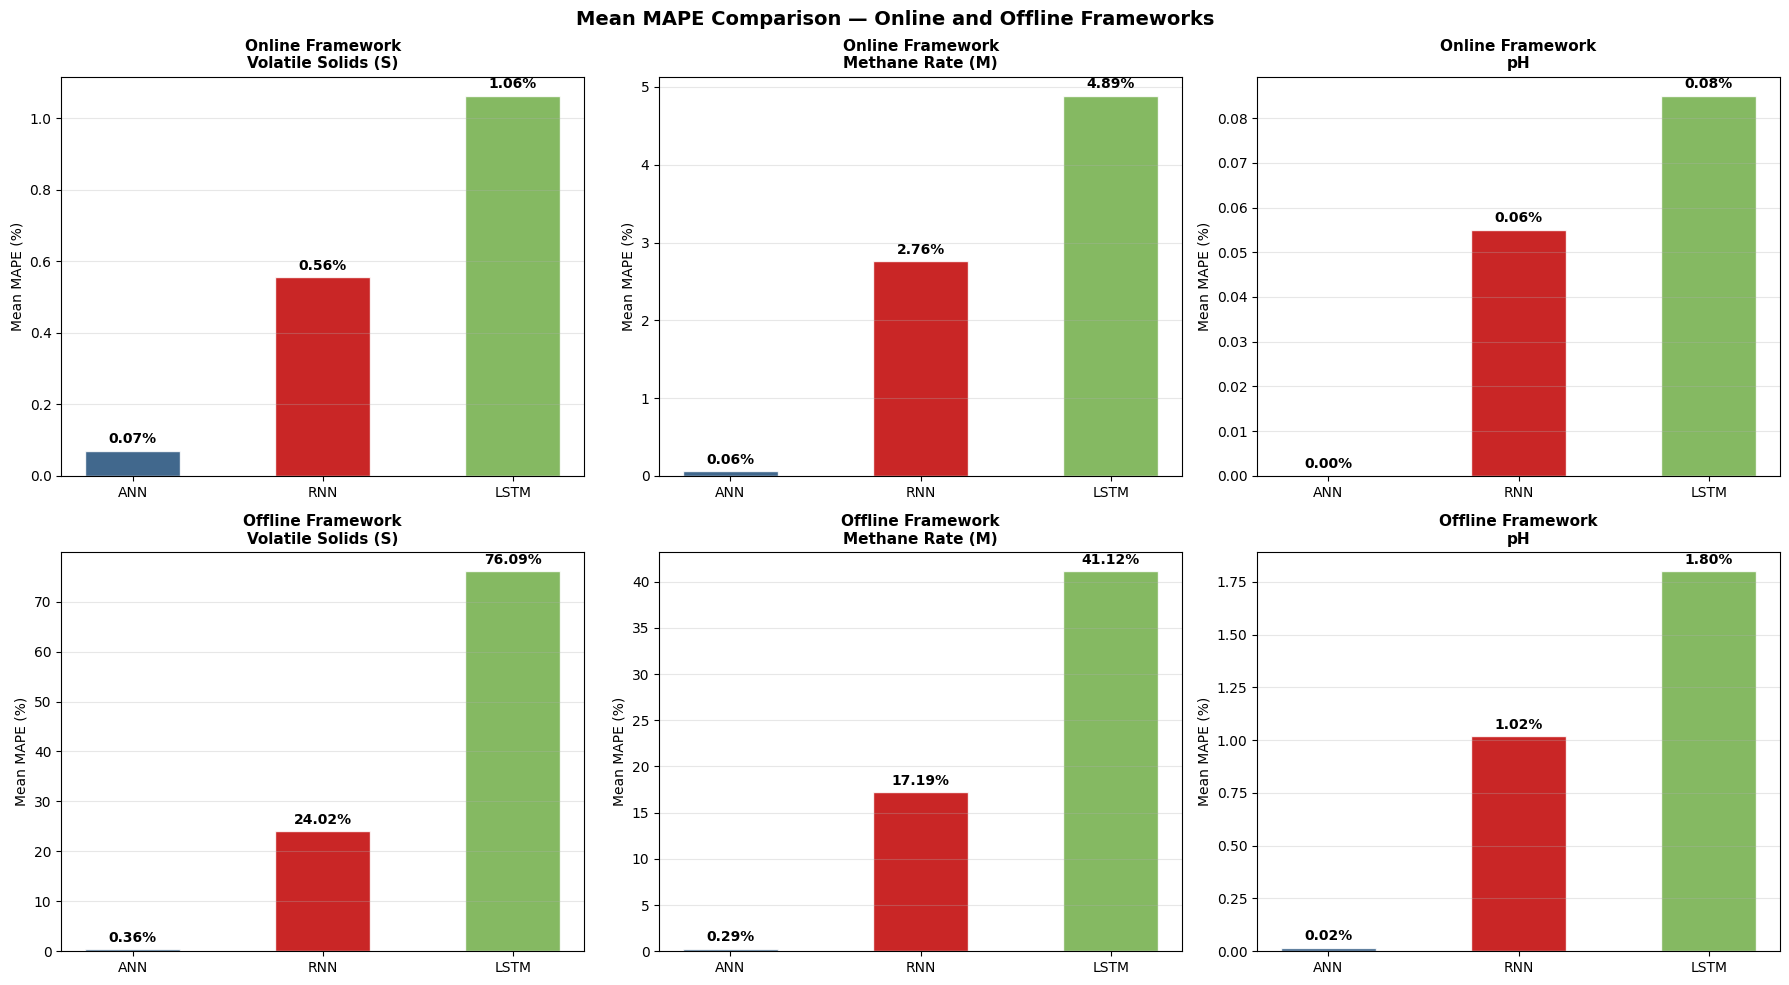

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
var_keys  = ['S', 'M', 'pH']
var_names = ['Volatile Solids (S)', 'Methane Rate (M)', 'pH']
frameworks = [online, offline]
framework_labels = ['Online Framework', 'Offline Framework']

for fi, (framework, flabel) in enumerate(zip(frameworks, framework_labels)):
    for vi, (vkey, vname) in enumerate(zip(var_keys, var_names)):
        ax = axes[fi, vi]
        means = [np.mean(framework[m][vkey]) for m in models]
        bars  = ax.bar(models, means,
                       color=[colors[m] for m in models],
                       alpha=0.85, edgecolor='white', width=0.5)
        ax.set_title(f"{flabel}\n{vname}", fontweight='bold', fontsize=11)
        ax.set_ylabel('Mean MAPE (%)')
        ax.grid(True, alpha=0.3, axis='y')
        for bar, val in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + max(means)*0.02,
                    f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Mean MAPE Comparison — Online and Offline Frameworks',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Per-Run Offline MAPE - All 4 Test Conditions

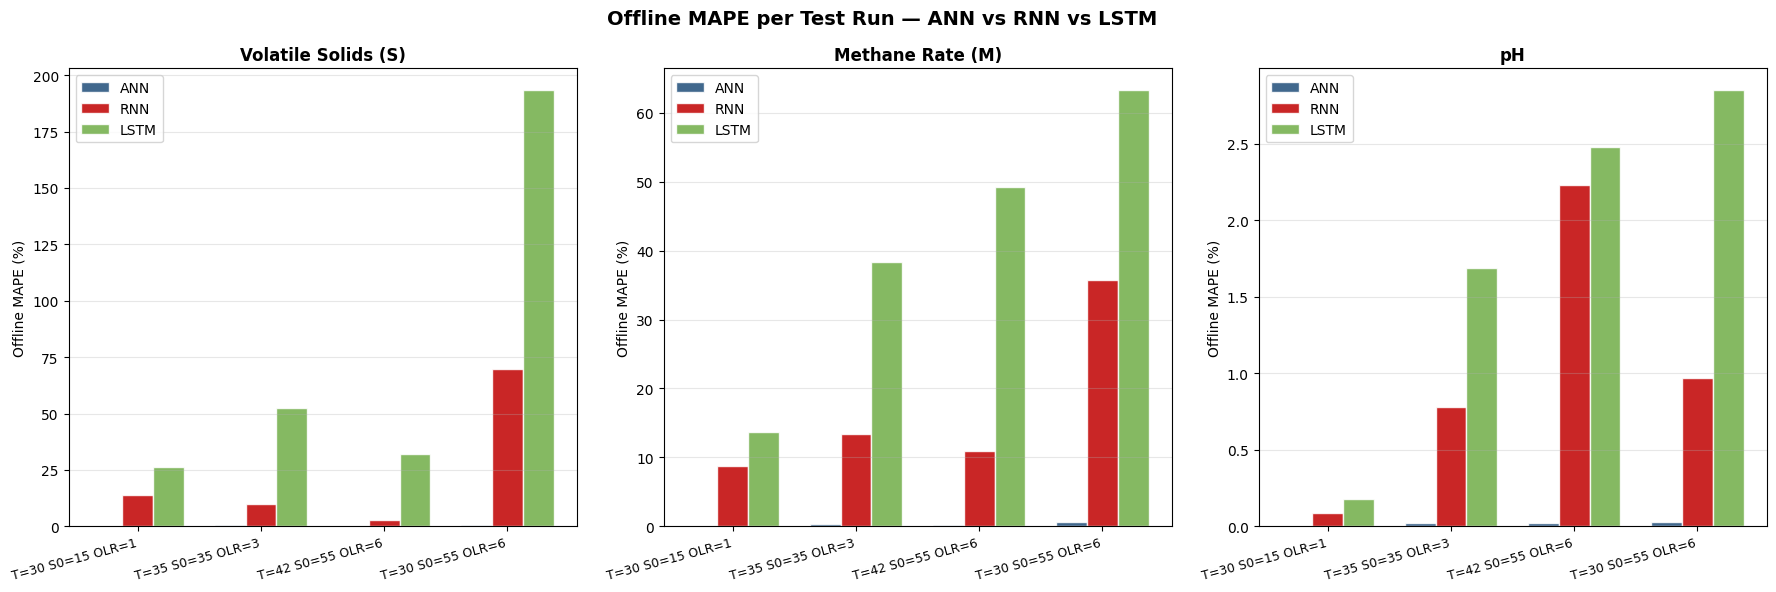

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
x     = np.arange(len(run_labels))
width = 0.25

for vi, (vkey, vname) in enumerate(zip(var_keys, var_names)):
    ax = axes[vi]
    for mi, m in enumerate(models):
        ax.bar(x + (mi - 1) * width, offline[m][vkey], width,
               label=m, color=colors[m], alpha=0.85, edgecolor='white')

    ax.set_title(f'{vname}', fontweight='bold', fontsize=12)
    ax.set_ylabel('Offline MAPE (%)')
    ax.set_xticks(x)
    ax.set_xticklabels(run_labels, rotation=15, ha='right', fontsize=9)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Offline MAPE per Test Run — ANN vs RNN vs LSTM',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Training metrics vs offline performance

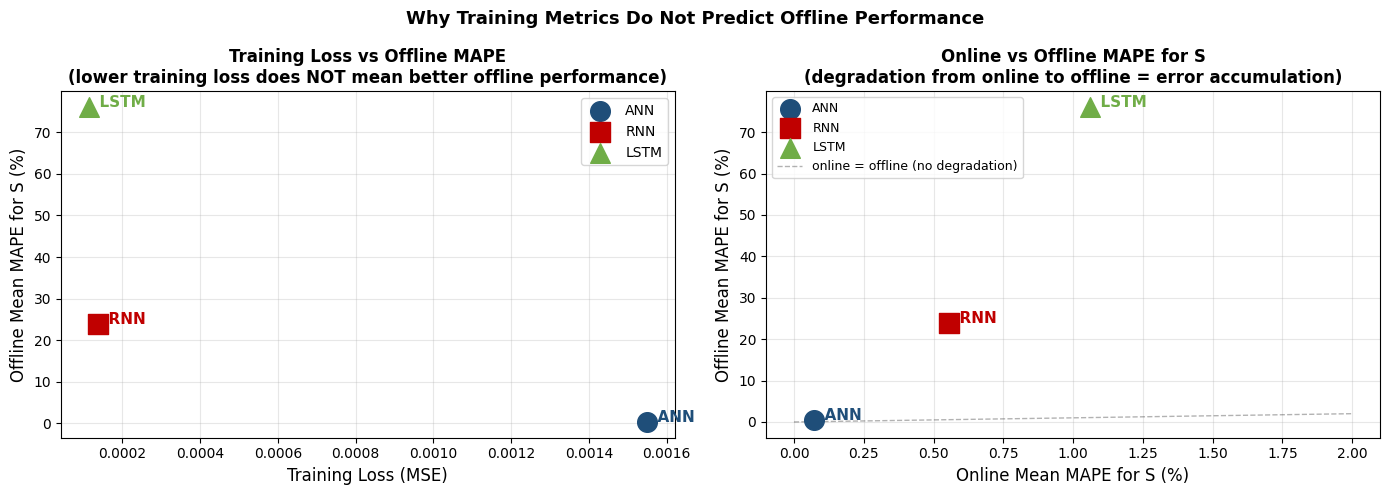

Key observation:
  ANN:  online S = 0.07%   offline S = 0.36%
  RNN:  online S = 0.56%   offline S = 24.02%
  LSTM: online S = 1.06%  offline S = 76.09%

The ANN degrades from 0.07% to 0.45% (factor of 6x).
The RNN degrades from 0.56% to 24.02% (factor of 43x).
The LSTM degrades from 1.06% to 76.09% (factor of 72x).
More memory = more error accumulation in offline simulation.


In [5]:
# scatter plot: training loss vs offline S MAPE
# shows that lower training loss does NOT predict better offline performance
training_losses = {'ANN': 0.001549, 'RNN': 0.000138, 'LSTM': 0.000114}
offline_S_mean  = {m: np.mean(offline[m]['S']) for m in models}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# left: training loss vs offline MAPE S
for m in models:
    axes[0].scatter(training_losses[m], offline_S_mean[m],
                    color=colors[m], s=200, marker=markers[m],
                    label=m, zorder=5)
    axes[0].annotate(f"  {m}", (training_losses[m], offline_S_mean[m]),
                     fontsize=11, fontweight='bold', color=colors[m])

axes[0].set_xlabel('Training Loss (MSE)', fontsize=12)
axes[0].set_ylabel('Offline Mean MAPE for S (%)', fontsize=12)
axes[0].set_title('Training Loss vs Offline MAPE\n(lower training loss does NOT mean better offline performance)',
                  fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=10)

# right: online vs offline MAPE S, shows error accumulation effect
for m in models:
    axes[1].scatter(np.mean(online[m]['S']), offline_S_mean[m],
                    color=colors[m], s=200, marker=markers[m],
                    label=m, zorder=5)
    axes[1].annotate(f"  {m}", (np.mean(online[m]['S']), offline_S_mean[m]),
                     fontsize=11, fontweight='bold', color=colors[m])

axes[1].plot([0, 2], [0, 2], 'k--', alpha=0.3, linewidth=1,
             label='online = offline (no degradation)')
axes[1].set_xlabel('Online Mean MAPE for S (%)', fontsize=12)
axes[1].set_ylabel('Offline Mean MAPE for S (%)', fontsize=12)
axes[1].set_title('Online vs Offline MAPE for S\n(degradation from online to offline = error accumulation)',
                  fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=9)

plt.suptitle('Why Training Metrics Do Not Predict Offline Performance',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key observation:")
print(f"  ANN:  online S = {np.mean(online['ANN']['S']):.2f}%   offline S = {np.mean(offline['ANN']['S']):.2f}%")
print(f"  RNN:  online S = {np.mean(online['RNN']['S']):.2f}%   offline S = {np.mean(offline['RNN']['S']):.2f}%")
print(f"  LSTM: online S = {np.mean(online['LSTM']['S']):.2f}%  offline S = {np.mean(offline['LSTM']['S']):.2f}%")
print()
print("The ANN degrades from 0.07% to 0.45% (factor of 6x).")
print("The RNN degrades from 0.56% to 24.02% (factor of 43x).")
print("The LSTM degrades from 1.06% to 76.09% (factor of 72x).")
print("More memory = more error accumulation in offline simulation.")

In [6]:
figs = [plt.figure(i) for i in plt.get_fignums()]
names = [
    'comparison_online_offline_grid.png',
    'comparison_per_run_offline.png',
    'comparison_training_vs_offline.png',
]
for fig, name in zip(figs, names):
    fig.savefig(name, dpi=150, bbox_inches='tight')
    print(f"saved: {name}")

## 6. Final summary table

In [7]:
print("=" * 75)
print("FINAL PROJECT SUMMARY — ALL MODELS")
print("=" * 75)
print()
print("ARCHITECTURE:")
print(f"  ANN  : Net(5, 20, 15, 3)          483 parameters")
print(f"  RNN  : RNNModel(5, 20, 1, 3)       603 parameters")
print(f"  LSTM : LSTMModel(5, 30, 2, 3)     7083 parameters")
print()
print("TRAINING (final MSE loss, R squared):")
print(f"  ANN  : loss=0.001549   dS=0.9982  dM=0.9984  dpH=0.9989")
print(f"  RNN  : loss=0.000138   dS=0.9993  dM=0.9993  dpH=0.9977")
print(f"  LSTM : loss=0.000114   dS=0.9995  dM=0.9995  dpH=0.9980")
print()
print("ONLINE MEAN MAPE:")
print(f"  {'Model':<8} {'S':>8} {'M':>8} {'pH':>8}")
for m in models:
    print(f"  {m:<8} {np.mean(online[m]['S']):>7.2f}%  "
          f"{np.mean(online[m]['M']):>7.2f}%  {np.mean(online[m]['pH']):>7.2f}%")
print()
print("OFFLINE MEAN MAPE:")
print(f"  {'Model':<8} {'S':>8} {'M':>8} {'pH':>8}  {'Verdict'}")
verdicts = {'ANN': 'EXCELLENT', 'RNN': 'POOR', 'LSTM': 'UNACCEPTABLE'}
for m in models:
    print(f"  {m:<8} {np.mean(offline[m]['S']):>7.2f}%  "
          f"{np.mean(offline[m]['M']):>7.2f}%  "
          f"{np.mean(offline[m]['pH']):>7.2f}%  {verdicts[m]}")
print()
print("WINNER: ANN — Net(5, 20, 15, 3)")
print()


FINAL PROJECT SUMMARY — ALL MODELS

ARCHITECTURE:
  ANN  : Net(5, 20, 15, 3)          483 parameters
  RNN  : RNNModel(5, 20, 1, 3)       603 parameters
  LSTM : LSTMModel(5, 30, 2, 3)     7083 parameters

TRAINING (final MSE loss, R squared):
  ANN  : loss=0.001549   dS=0.9982  dM=0.9984  dpH=0.9989
  RNN  : loss=0.000138   dS=0.9993  dM=0.9993  dpH=0.9977
  LSTM : loss=0.000114   dS=0.9995  dM=0.9995  dpH=0.9980

ONLINE MEAN MAPE:
  Model           S        M       pH
  ANN         0.07%     0.06%     0.00%
  RNN         0.56%     2.76%     0.06%
  LSTM        1.06%     4.89%     0.08%

OFFLINE MEAN MAPE:
  Model           S        M       pH  Verdict
  ANN         0.36%     0.29%     0.02%  EXCELLENT
  RNN        24.02%    17.19%     1.02%  POOR
  LSTM       76.09%    41.12%     1.80%  UNACCEPTABLE

WINNER: ANN — Net(5, 20, 15, 3)

